# 17.14 訓練時能先體驗量化誤差嗎？


PTQ在權重固定後轉換；另一種做法在訓練期間就讓前向用量化後的數字，嘗試教模型適應格子誤差，叫**量化感知訓練（Quantization-Aware Training，QAT）**。它需要訓練數據與參數更新，和只收集範圍的校準不同。

先用`[0.1,0.4,0.9]`看問題。4-bit對稱scale是0.9/7，碼`[1,3,7]`，還原約`[0.1286,0.3857,0.9]`。round在同一格內幾乎不隨小變化改變，直接梯度通常0，難教上游。

QAT常用**模擬量化（fake quantization）**：前向確實用還原值，反向刻意近似成直接通過，叫**直通估計（STE）**。它不是round真正的導數。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

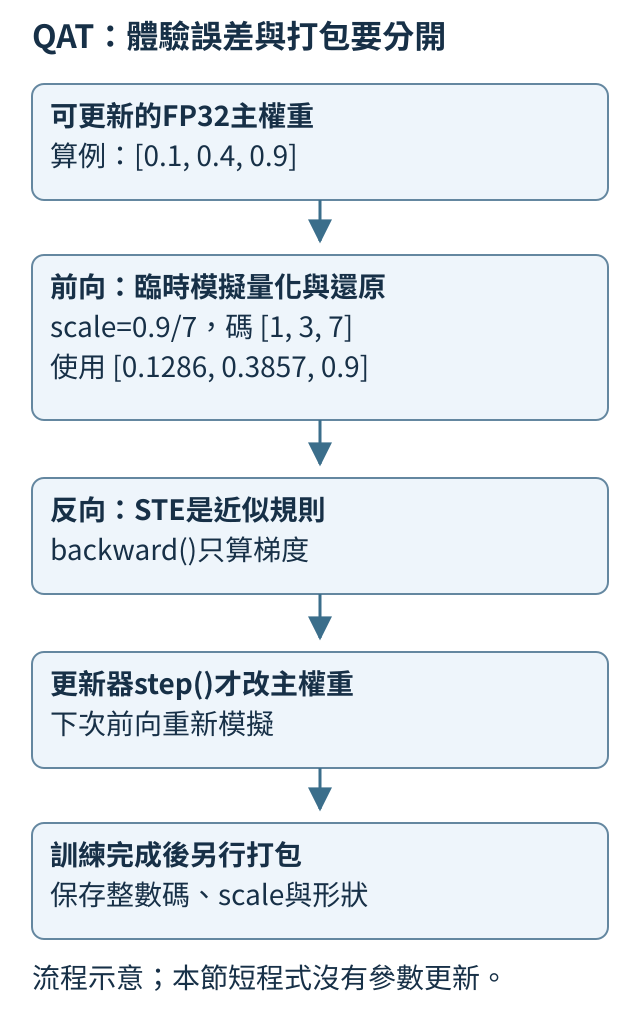

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-17-qat-flow.svg")))

In [3]:
import torch
from tiny_perceptron.quantization import fake_quantize

x = torch.tensor([0.1, 0.4, 0.9], requires_grad=True)
y = fake_quantize(x, bits=4)
y.sum().backward()
print("向前", y.detach().round(decimals=4).tolist())
print("STE梯度", x.grad.tolist())
hard = x.detach().clone().requires_grad_()
scale = 0.9 / 7
plain = (hard / scale).round() * scale
plain.sum().backward()
print("直接round梯度", hard.grad.tolist())

向前 [0.12860000133514404, 0.385699987411499, 0.8999999761581421]
STE梯度 [1.0, 1.0, 1.0]
直接round梯度 [0.0, 0.0, 0.0]


本工具以`x+(還原值−x).detach()`實現STE。前向x相消，留下還原值；反向括號項不追蹤，只走外面的x。對y總和求導，所以STE梯度`[1,1,1]`，直接round則`[0,0,0]`。此程式只求梯度，沒有更新器`step()`，沒有訓練網路或輸出小文件。

完整QAT仍保存可更新的浮點主權重，每次前向重做模擬；訓練後另轉成實際打包格式，再用部署版檢查。模擬和部署規則若不一致，適應的誤差可能對不上。

有梯度只說明可以學，效果需要同起點、同資料、同更新預算的對照。既有一份比較中，同樣350次更新，普通微調後PTQ答對6／10，QAT後packed4答對4／10；這份小模型沒有因此更好。完整條件留在補充，不能將單向量梯度或「預先適應」當成品質保證。

練習只將第一條代價`y.sum()`改`y.square().sum()`，STE梯度變成2y，約`[0.2571,0.7714,1.8]`。這分開了代價提供的訊號與STE近似傳遞規則。

<details>
<summary>補充：既有實驗、來源與完整測量範圍</summary>

[Jacob等人的模擬量化原文第3節](https://arxiv.org/abs/1712.05877v1)也分開浮點訓練圖與低位元推論圖；我們只採其中「先體驗捨入誤差」的思路，沒有複製其整數推論引擎。[STE原文第4節](https://arxiv.org/abs/1308.3432v1)把直接傳梯度稱為有偏的估計，正好提醒我們：有梯度是能更新的條件，品質改善另靠結果證明。

正式流程從[T.4的直接SFT底座](https://birdhackor.github.io/tiny-perceptron-vlm/training.html#T.4)各複製一份，以相同初始化、相同抽題索引、seed42、batch16與學習率0.003，分別做350次普通FP32微調與350次weight-only QAT。兩支都實際完成350次optimizer更新、各讀39,348個回答與EOS目標。QAT針對每個輸出列以最大絕對值除7求scale，捨入至-7至7、反量化後前向，反向則採上述STE；和最後`QuantizedLinear`的規則相同。這與上方單向量、共用一把刻度的CPU例子不同，正式模型使用逐列刻度。

表中的PTQ是post-training quantization（訓練後量化）：先完成普通浮點訓練或微調，再把固定權重轉成低位元表示；PTQ4表示四位元版本。QAT則在訓練時就模擬量化誤差。[17.9](https://birdhackor.github.io/tiny-perceptron-vlm/17.9.html)示範了PTQ的轉換流程。NLL是把標準答案與EOS各位置的負對數代價取平均，計算方法可回看[5.1](https://birdhackor.github.io/tiny-perceptron-vlm/5.1.html)；越小表示這批目標的平均預測代價越低，還不是模型自己生成時的答對率。

| 共同底座的支線 | 額外更新 | 測試答對／10題 | 測試回答NLL／69目標 |
| --- | ---: | ---: | ---: |
| 原FP32 | 0 | 5 | 0.5058 |
| 原版直接PTQ4 | 0 | 4 | 0.5262 |
| 普通FP32微調 | 350 | 6 | 0.4896 |
| 普通微調後PTQ4 | 350 | 6 | 0.4066 |
| QAT浮點主權重 | 350 | 4 | 0.5398 |
| QAT後正式packed4 | 350 | 4 | 0.5979 |

公平的QAT對照是兩支都有350次更新的packed版，而不是只和零次更新的直接PTQ比。驗證五題上，QAT後packed4與普通微調後PTQ4各答對2/5；按相同36個回答與EOS目標計算，前者NLL是0.5273，後者是1.1811。最後十題的排序卻反過來：QAT後packed4的NLL是0.5979，普通微調後PTQ4是0.4066，QAT還少答對兩題。驗證卷上較低的代價，沒有在這份最後考卷維持同樣優勢。因此不能用「預先適應」保證成功，也不能看過最後題再改設定把失敗藏掉。六版測試都EOS10/10且無非法控制ID，停止正常仍不等於答案正確。

在一筆完整帶標準答案前文的測試輸入上，QAT模擬forward與重新載入的packed4最大logit差為0；這檢查部署規則對上，沒有證明模型答對。還要分清「保存數字」與「保存計算方式」：`qat_float.pt`只保留浮點主權重，普通FP32載入不會自動啟用fake quant；真正打包後的部署檔是`model.pt`。完整條件與產物可查[QAT實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/qat.json)。

已有[T.4直接SFT實驗](https://birdhackor.github.io/tiny-perceptron-vlm/training.html#T.4)的`model.pt`與`dataset.json`時，下列指令從同一底座重做普通微調、QAT與打包比較，再試用QAT部署檔。這是重做全流程的入口；正式L4數字不等於你CPU重跑的時間：

```bash
.venv/bin/python -m scripts.course_experiments.run --experiment qat --device cpu
.venv/bin/python scripts/infer.py outputs/course-experiments/course-v1/qat/model.pt --chat --prompt "color=red;shape=square;pitch=high;describe" --tokens 24 --json
```

這題標準答案是`square`，正式QAT部署版卻答`circle`，普通微調後PTQ答`square`。同樣的四位元儲存仍可能保存不同決策；兩支的tensor bytes相同，檔案bytes的差還包含metadata，不能當成QAT減少參數的證據。

</details>
